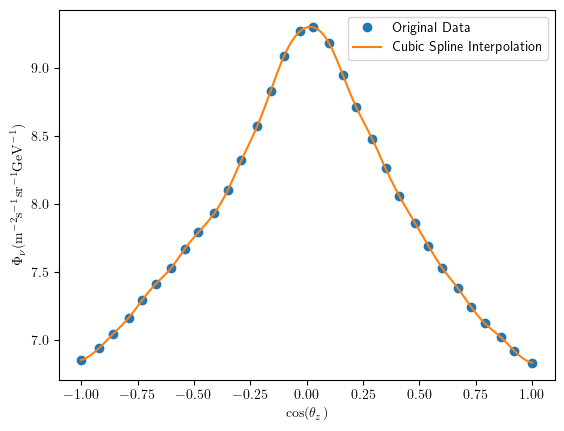

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
# latex
plt.rcParams['text.usetex'] = True
flux_data = np.loadtxt('flux_zenith.txt', delimiter=',')
cos_zenith = flux_data[:, 0]
zenith_interp = np.linspace(-1, 1, 100)
# interpolated flux values
flux_values = flux_data[:, 1]
flux_interp = interp.interp1d(cos_zenith, flux_values, kind='cubic')(zenith_interp)
plt.plot(cos_zenith, flux_values, 'o', label='Original Data')
plt.plot(zenith_interp, flux_interp, '-', label='Cubic Spline Interpolation')
plt.xlabel(r'$\cos(\theta_z)$')
plt.ylabel(r'$\Phi_{\nu}(\mathrm{m}^{-2} \mathrm{s}^{-1} \mathrm{sr}^{-1} \mathrm{GeV}^{-1})$')
plt.legend()
plt.show()

In [26]:
# Get fraction of the flux between cos(zenith) = -0.267 to 0.0708
from scipy.integrate import simpson
integration_range = zenith_interp[(zenith_interp >= -0.267) & (zenith_interp <= 0.0708)]
flux_integration = flux_interp[(zenith_interp >= -0.267) & (zenith_interp <= 0.0708)]
band_flux = simpson(flux_integration, integration_range)

integration_range_2 = zenith_interp[(zenith_interp >= -1) & (zenith_interp <= 1)]
flux_integration_2 = flux_interp[(zenith_interp >= -1) & (zenith_interp <= 1)]
total_flux = simpson(flux_integration_2, integration_range_2)

flux_fraction = band_flux / total_flux
print(flux_fraction)

0.18442831037749746


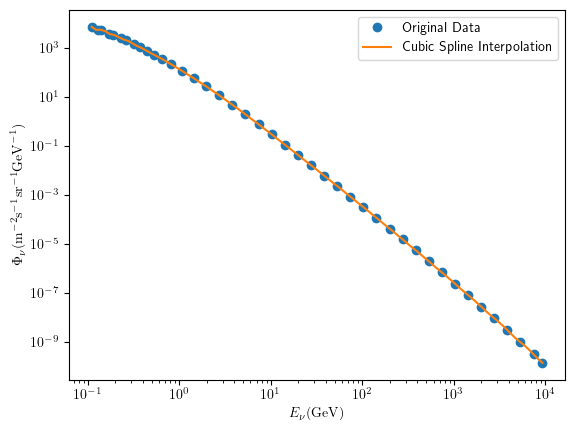

In [27]:
flux_spectrum = np.loadtxt('flux_energy.txt', delimiter=',')
energy = flux_spectrum[:, 0]
flux_energy_values = flux_spectrum[:, 1]/(energy**3)
# interpolated flux values
energy_interp = np.logspace(np.log10(min(energy)), np.log10(max(energy))-1e-5, 100)
flux_energy_interp = interp.interp1d(energy, flux_energy_values, kind='cubic')(energy_interp)
plt.loglog(energy, flux_energy_values, 'o', label='Original Data')
plt.loglog(energy_interp, flux_energy_interp, '-', label='Cubic Spline Interpolation')
plt.xlabel(r'$E_{\nu} (\mathrm{GeV})$')
plt.ylabel(r'$\Phi_{\nu}(\mathrm{m}^{-2} \mathrm{s}^{-1} \mathrm{sr}^{-1} \mathrm{GeV}^{-1})$')
plt.legend()
plt.show()

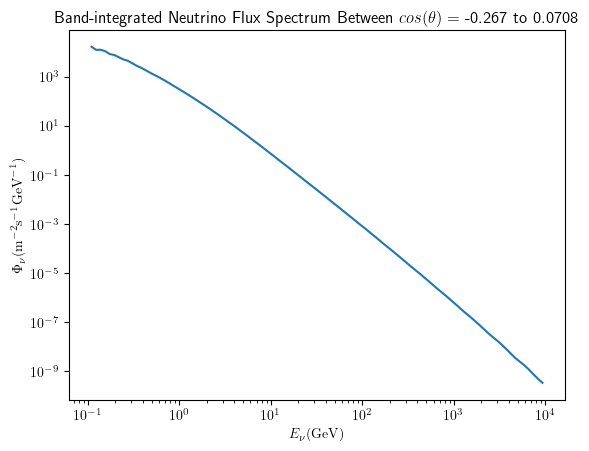

In [32]:
# band-integrated spectrum
plt.loglog(energy_interp, flux_energy_interp*flux_fraction*4*np.pi, '-')
plt.xlabel(r'$E_{\nu} (\mathrm{GeV})$')
plt.ylabel(r'$\Phi_{\nu}(\mathrm{m}^{-2} \mathrm{s}^{-1} \mathrm{GeV}^{-1})$')
plt.title(r'Band-integrated Neutrino Flux Spectrum Between $cos(\theta)$ = -0.267 to 0.0708')
plt.show()

In [36]:
2*0.2731198368628216*6371

3480.092961306073

In [34]:
np.cos(105.85 * np.pi / 180)

np.float64(-0.2731198368628216)